Importing Libraries


In [253]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Dataset Overview

In [254]:
df=pd.read_csv('/Users/sanjayduduka/Desktop/FS_Task02/data/WA_Fn-UseC_-Telco-Customer-Churn.csv.xls')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [255]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [256]:
df.shape

(7043, 21)

* The Telco Customer Churn dataset contains 7,043 customer records and 21 features related to customer demographics, services, billing, and churn status. The objective is to identify factors influencing customer retention and customer churn.

Data Quality Check


In [257]:
df.isnull().sum().sum()

np.int64(0)

In [258]:
df.duplicated().sum()

np.int64(0)

In [259]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [260]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'] = df['TotalCharges'].fillna(
    df['MonthlyCharges'] * df['tenure']
)

In [261]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [262]:
df.isnull().sum().sum()

np.int64(0)

* The dataset was examined for missing values, duplicate records, and data type inconsistencies.
* No duplicate records or missing values were found. 
* The TotalCharges column was converted to numeric format for analysis.

 Customer Churn Distribution

In [263]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

* Out of 7,043 customers, 1,869 customers churned while 5,174 customers remained active.

In [264]:
round(
    df['Churn'].value_counts(normalize=True)*100,
    2
)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

* Approximately 26.5% of customers have left the company, indicating a moderate customer retention challenge.

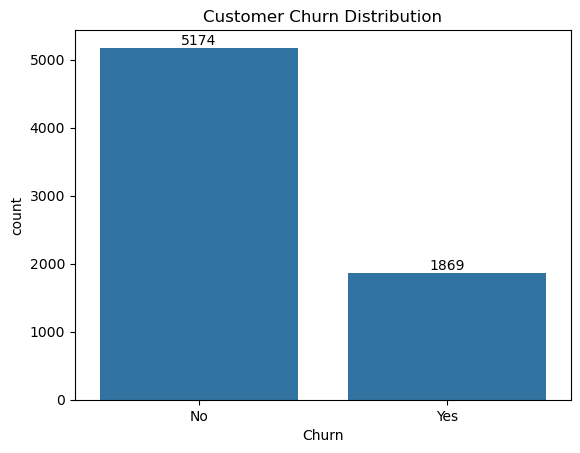

In [265]:
x=sns.countplot(
    x='Churn',
    data=df
)
x.bar_label(x.containers[0])

plt.title('Customer Churn Distribution')
plt.show()

Customer Tenure Statistics

In [266]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


* The average customer tenure is approximately 32 months, with monthly charges averaging around $65.
* Customers show varying levels of engagement, with some remaining active for up to 72 months.

Tenure Distribution by Churn


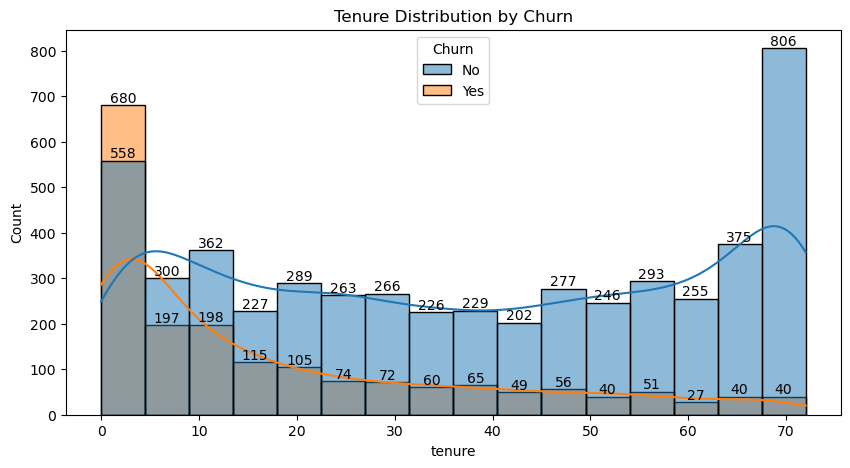

In [267]:
plt.figure(figsize=(10,5))

x=sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    kde=True
)
for i in x.containers:
    x.bar_label(i)

plt.title('Tenure Distribution by Churn')
plt.show()

* Customers with shorter tenure are more likely to churn, while long-term customers are more likely to stay.
* Customer loyalty increases over time. The highest churn occurs during the early stages of the customer lifecycle.


Tenure Boxplot Analysis
* Tenure Comparison Between Churned and Retained Customers
* Churned customers have a significantly lower median tenure compared to retained customers.

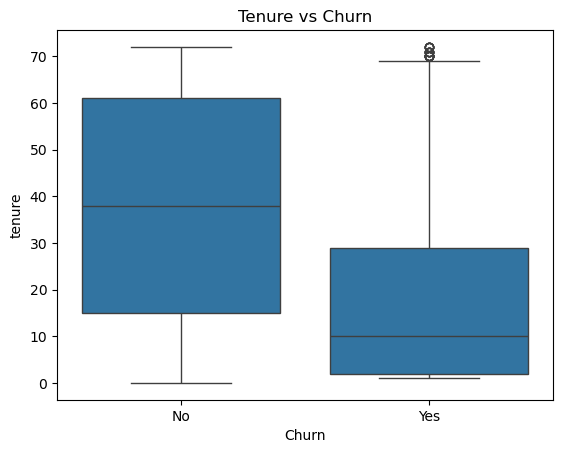

In [268]:
sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)
plt.title("Tenure vs Churn")
plt.show()

Monthly Charges Analysis

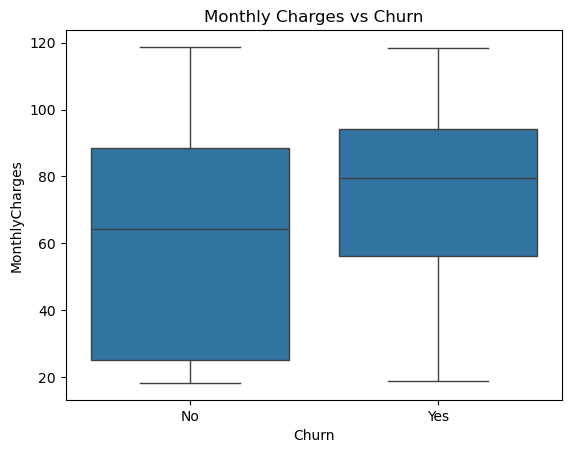

In [269]:
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)
plt.title("Monthly Charges vs Churn")
plt.show()

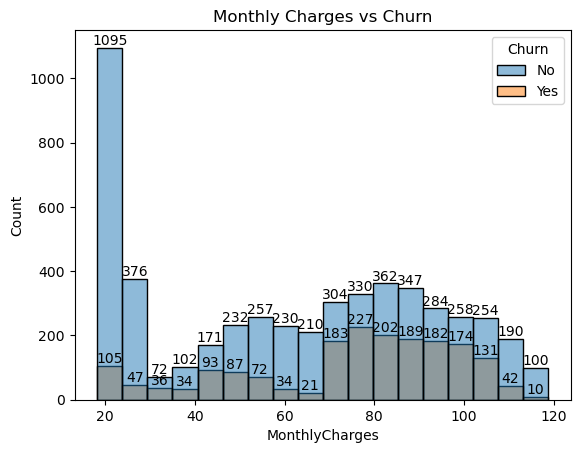

In [270]:
x=sns.histplot(
    data=df,
    x='MonthlyCharges',
    hue='Churn'
)
for i in x.containers:
    x.bar_label(i)

plt.title("Monthly Charges vs Churn")
plt.show()

* Customers who churn generally have higher monthly charges than customers who stay.
* Higher subscription costs may contribute to customer dissatisfaction and churn.

Contract Type Analysis

In [271]:
pd.crosstab(
    df['Contract'],
    df['Churn']
)

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [272]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
)*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


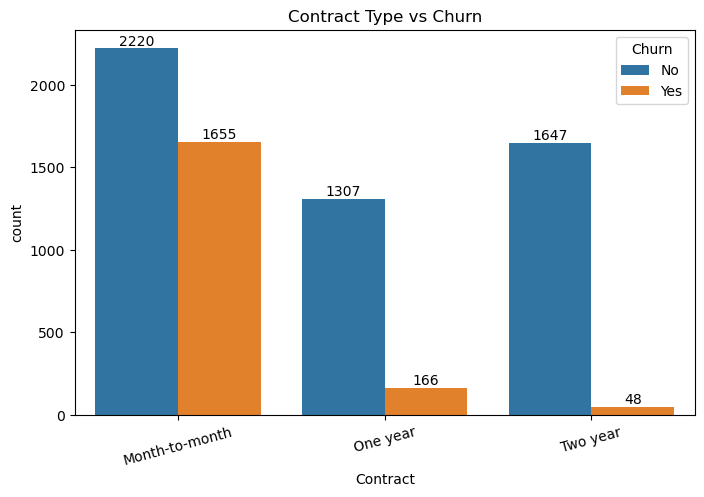

In [273]:
plt.figure(figsize=(8,5))

x = sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

for i in x.containers:
    x.bar_label(i)

plt.xticks(rotation=15)
plt.title('Contract Type vs Churn')
plt.show()

* Month-to-month customers have the highest churn rate, while customers with one-year and two-year contracts show significantly lower churn.
* Long-term contracts strongly improve customer retention.

Payment Method Analysis

In [274]:
pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
)*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


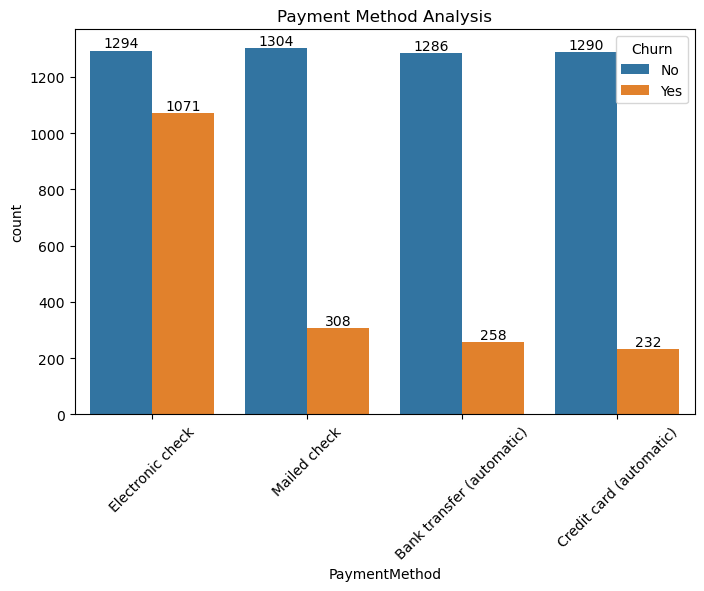

In [275]:
plt.figure(figsize=(8,5))

x=sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)
for i in x.containers:
    x.bar_label(i)
plt.title("Payment Method Analysis")

plt.xticks(rotation=45)
plt.show()

* Customers using Electronic Check show the highest churn rate (45.3%).
* Automatic payment methods are associated with better customer retention.

Internet Service Analysis

In [276]:
pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
)*100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


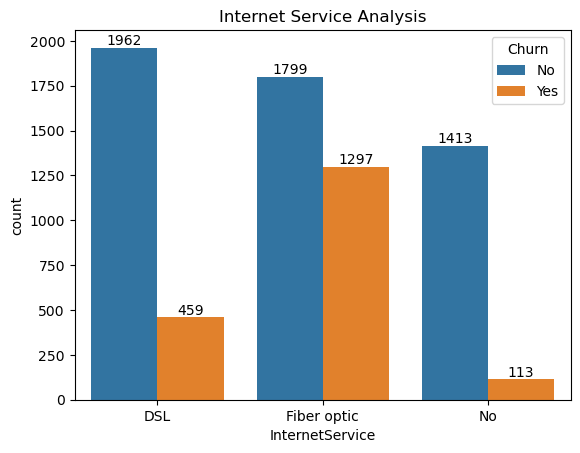

In [277]:
x=sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)
for i in x.containers:
    x.bar_label(i)
plt.title("Internet Service Analysis")
plt.show()

* Fiber Optic customers have the highest churn rate (41.9%) compared to DSL customers (19%).

Senior Citizen Customer Churn Analysis

In [278]:
pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
)*100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


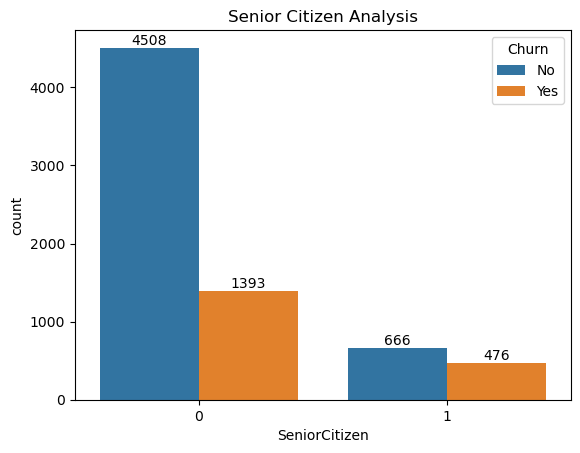

In [279]:
x=sns.countplot(
    x='SeniorCitizen',
    hue='Churn',
    data=df
)
for i in x.containers:
    x.bar_label(i)
plt.title("Senior Citizen Analysis")
plt.show()

* Senior citizens have a churn rate of 41.7%, while non-senior customers have a churn rate of 23.6%.
* Senior customers are significantly more likely to leave the service.

Gender-Based Churn Analysis

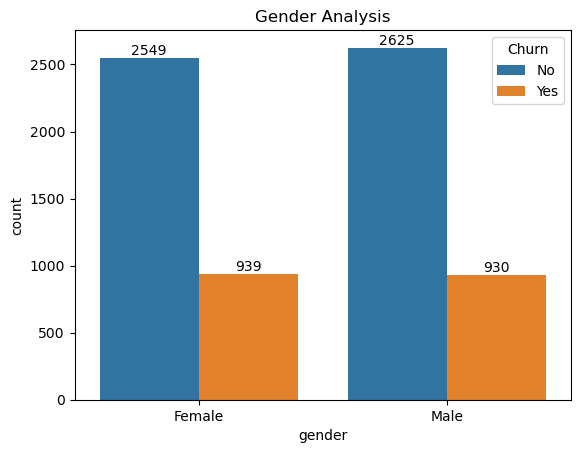

In [280]:
x=sns.countplot(
    x='gender',
    hue='Churn',
    data=df
)
for i in x.containers:
    x.bar_label(i)   
plt.title("Gender Analysis")
plt.show()

* Churn levels are nearly identical for male and female customers.
* Gender has minimal influence on customer churn behavior.

Correlation Analysis

In [281]:
df_corr = df.copy()

df_corr['Churn'] = df_corr['Churn'].map({
    'No':0,
    'Yes':1
})

In [282]:
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Churn'
]

corr = df_corr[num_cols].corr()
corr

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.826178,0.651174,1.000000,-0.198324
Churn,-0.352229,0.193356,-0.198324,1.000000


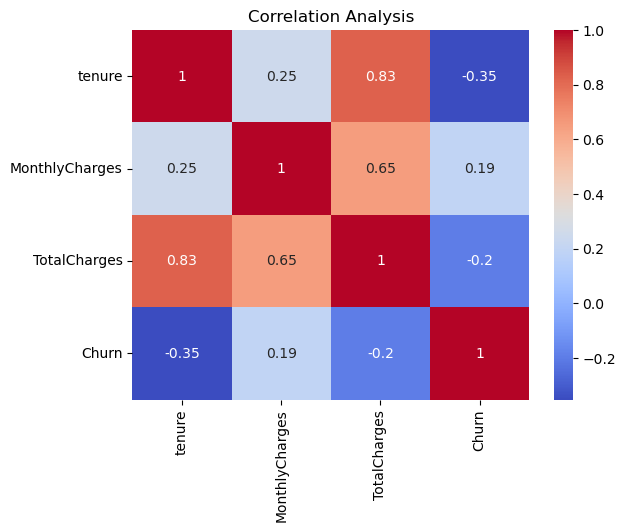

In [283]:
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Analysis")
plt.show()

* Tenure has the strongest negative relationship with churn (-0.35), while Monthly Charges show a weak positive relationship (0.19).
* Customer tenure is the most important numerical indicator of retention.

Export Processed Data

In [284]:
df.to_csv('Cleaned_Customer_Churn.csv', index=False)

Final Conclusion
*Title
>Key Findings and Recommendations

Key Findings
* Overall churn rate is 26.5%.
* Month-to-month customers show the highest churn.
* Customers with shorter tenure are more likely to leave.
* Higher monthly charges are associated with increased churn.
* Fiber Optic customers exhibit high churn rates.
* Senior citizens churn significantly more than non-senior customers.
* Gender has little impact on churn

Business Recommendations
1. Encourage long-term contract adoption.
2. Improve onboarding for new customers.
3. Promote automatic payment methods.
4. Review Fiber Optic service quality and pricing.
5. Create dedicated retention programs for senior customers.